In [ ]:
import torch
from IPython import display
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

In [ ]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 351kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.35MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]


In [ ]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [ ]:
mnist_train[0][0].shape


torch.Size([1, 28, 28])

In [ ]:
def get_fashion_mnist_labels(labels):
    """Fashion-MNIST veri kümesi için metin etiketleri döndürün."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Görsellerin bir listesini çizin"""
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    # axes tek boyutlu değilse düzleştir
    if num_rows * num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (ax, img) in enumerate(zip(axes, imgs)):

        if torch.is_tensor(img):
            img = img.detach().cpu()

            # (C,H,W) ise (H,W,C)'ye çevir
            if img.ndim == 3:
                img = img.permute(1, 2, 0)

            ax.imshow(img.numpy())
        else:
            ax.imshow(img)

        ax.axis('off')  # eksenleri gizle

        if titles:
            ax.set_title(titles[i])

    return axes

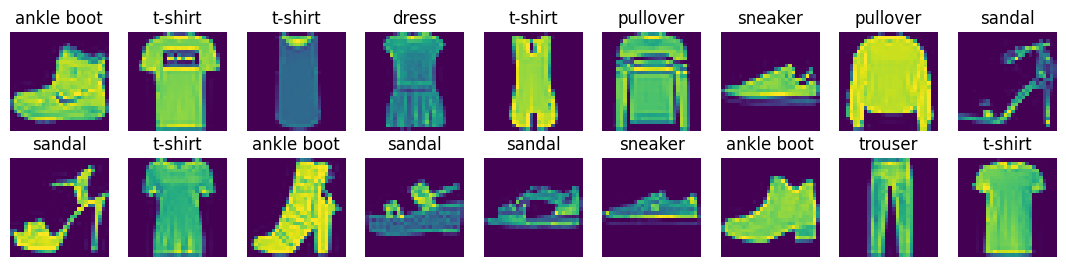

In [ ]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

In [ ]:
batch_size = 256

def get_dataloader_workers():
    """Verileri okumak için 4 işlem kullanın."""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
import time

start = time.time()

for X, y in train_iter:
    continue

elapsed = time.time() - start

print(f"{elapsed:.2f} sec")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


6.97 sec


In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Fashion-MNIST veri kümesini indirin ve ardından belleğe yükleyin."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))


In [ ]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break


torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
